# Music Genre Classification using GTZAN Dataset

## 1. Business Understanding

### Problem Statement
Music genre classification is a fundamental problem in the field of music information retrieval (MIR). With the exponential growth of digital music libraries and streaming platforms, automatically categorizing music into genres has become crucial for:

- **Music Discovery**: Helping users find new music based on their preferences
- **Content Organization**: Organizing large digital music libraries efficiently
- **Recommendation Systems**: Powering music recommendation algorithms
- **Intellectual Property**: Assisting in copyright detection and management

### Project Objective
The goal of this project is to build a machine learning model that can accurately classify audio tracks into one of 10 distinct music genres using extracted audio features from the GTZAN dataset.

**Genres to Classify**: Blues, Classical, Country, Disco, Hip-hop, Jazz, Metal, Pop, Reggae, Rock

### Success Criteria
- Achieve high classification accuracy across all genres
- Build a robust model that generalizes well to unseen audio data
- Understand which audio features are most discriminative for genre classification

This analysis will follow a comprehensive ML pipeline: data collection, preprocessing, exploratory analysis, feature engineering, model training, and evaluation.


---

## 2. Data Collection

### Dataset Overview
The GTZAN dataset is a widely-used benchmark dataset in music genre classification. It contains audio tracks from 10 different genres, with each track segmented into 3-second clips. The features extracted from these clips include:

- **MFCCs (Mel-frequency Cepstral Coefficients)**: 20 coefficients capturing timbral characteristics
- **Spectral Features**: Centroid, bandwidth, rolloff, zero-crossing rate
- **Chroma Features**: Representing harmonic content
- **RMS Energy**: Root Mean Square energy for loudness estimation
- **Harmony and Perceptr**: Additional timbral features
- **Tempo**: Beat tracking information

Let's load the dataset and examine its structure.


### 2.1 Import necessary libraries

In [1]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")

# print("Path to dataset files:", path)

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


### 2.2 Dataset Overview

In [3]:
# Load the dataset
df = pd.read_csv(r'Data\features_3_sec.csv')

print(f"\nShape of dataset: {df.shape}")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

df.head()


Shape of dataset: (9990, 60)
Number of samples: 9990
Number of features: 60


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


### 2.3 Dataset Information

In [4]:
# Display dataset information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9990 entries, 0 to 9989
Data columns (total 60 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   filename                 9990 non-null   object 
 1   length                   9990 non-null   int64  
 2   chroma_stft_mean         9990 non-null   float64
 3   chroma_stft_var          9990 non-null   float64
 4   rms_mean                 9990 non-null   float64
 5   rms_var                  9990 non-null   float64
 6   spectral_centroid_mean   9990 non-null   float64
 7   spectral_centroid_var    9990 non-null   float64
 8   spectral_bandwidth_mean  9990 non-null   float64
 9   spectral_bandwidth_var   9990 non-null   float64
 10  rolloff_mean             9990 non-null   float64
 11  rolloff_var              9990 non-null   float64
 12  zero_crossing_rate_mean  9990 non-null   float64
 13  zero_crossing_rate_var   9990 non-null   float64
 14  harmony_mean            

### 2.4 Statistical Summary

In [5]:
# Statistical summary
df.describe()


,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
count,9990.0,9990.000000,9990.000000,9990.000000,9.990000e+03,9990.000000,9.990000e+03,9990.000000,9.990000e+03,9990.000000,...,9990.000000,9990.000000,9990.000000,9990.000000,9990.000000,9990.000000,9990.000000,9990.000000,9990.000000,9990.000000
mean,66149.0,0.379534,0.084876,0.130859,2.676388e-03,2199.219431,4.166727e+05,2241.385959,1.182711e+05,4566.076592,...,1.448240,49.988755,-4.198706,51.962753,0.739943,52.488851,-2.497306,54.973829,-0.917584,57.322614
std,0.0,0.090466,0.009637,0.068545,3.585628e-03,751.860611,4.349644e+05,543.854449,1.013505e+05,1642.065335,...,5.735149,34.442816,5.677379,36.400669,5.181313,38.177120,5.111799,41.585677,5.253243,46.444212
min,66149.0,0.107108,0.015345,0.000953,4.379535e-08,472.741636,8.118813e+02,499.162910,1.183520e+03,658.336276,...,-26.850016,1.325786,-27.809795,1.624544,-20.733809,3.437439,-27.448456,3.065302,-35.640659,0.282131
25%,66149.0,0.315698,0.079833,0.083782,6.145900e-04,1630.680158,1.231961e+05,1887.455790,4.876553e+04,3378.311110,...,-2.227478,29.584894,-7.951722,29.863448,-2.516638,29.636197,-5.734123,30.496412,-4.004475,30.011365
50%,66149.0,0.384741,0.085108,0.121253,1.491318e-03,2208.628236,2.650692e+05,2230.575595,8.996072e+04,4631.377892,...,1.461623,41.702393,-4.443021,42.393583,0.733772,41.831377,-2.702366,43.435253,-1.030939,44.332155
75%,66149.0,0.442443,0.091092,0.176328,3.130862e-03,2712.581884,5.624152e+05,2588.340505,1.585674e+05,5591.634521,...,5.149752,59.274619,-0.726945,61.676964,3.888734,62.033906,0.514246,65.328602,2.216603,68.210421
max,66149.0,0.749481,0.120964,0.442567,3.261522e-02,5432.534406,4.794119e+06,3708.147554,1.235143e+06,9487.446477,...,39.144405,683.932556,34.048843,529.363342,36.970322,629.729797,31.365425,1143.230591,34.212101,910.473206


### 2.5 GENRE DISTRIBUTION ANALYSIS

Samples per genre:
label
blues        1000
classical     998
country       997
disco         999
hiphop        998
jazz         1000
metal        1000
pop          1000
reggae       1000
rock          998
Name: count, dtype: int64

Total number of genres: 10


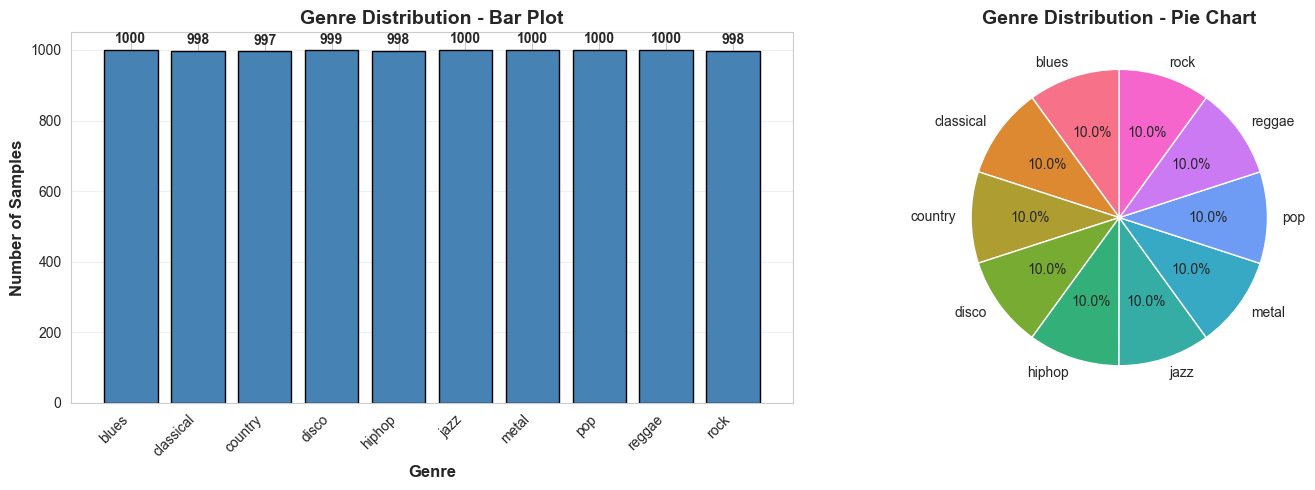

In [6]:
# Count samples per genre
genre_counts = df['label'].value_counts().sort_index()
print("Samples per genre:")
print(genre_counts)
print()

# Calculate statistics
print(f"Total number of genres: {df['label'].nunique()}")

# Visualize genre distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot
axes[0].bar(range(len(genre_counts)), genre_counts.values, color='steelblue', edgecolor='black')
axes[0].set_xticks(range(len(genre_counts)))
axes[0].set_xticklabels(genre_counts.index, rotation=45, ha='right')
axes[0].set_xlabel('Genre', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
axes[0].set_title('Genre Distribution - Bar Plot', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(genre_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')

# Pie chart
colors = sns.color_palette('husl', len(genre_counts))
axes[1].pie(genre_counts.values, labels=genre_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors)
axes[1].set_title('Genre Distribution - Pie Chart', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

---

## 3. Data Preprocessing and Data Preparation

### Preprocessing Steps

Data preprocessing is crucial for building an effective machine learning model. We will:

1. **Handle Missing Values**: Check for and handle any null or missing data
2. **Remove Duplicates**: Identify and drop duplicate records
3. **Outlier Detection**: Identify and analyze outliers in the data
4. **Encode Categorical Features**: Convert genre labels to numerical format
5. **Feature Scaling**: Standardize features to have similar scales
6. **Dimensionality Reduction**: Apply PCA analysis to understand feature space
7. **(Optional) Feature Binning/Binarization**: Binning continuous features to improve model interpretability

Let's start by examining the data quality.


### 3.1 Train-Test Split (Stratified)
#### Stratified Splitting:
We use stratified splitting to ensure that both training and test sets 
have the same proportion of each genre class. This is crucial for:
- Balanced evaluation
- Preventing bias toward majority classes
- Fair model comparison

Split ratio: 80% training, 20% testing

In [7]:
from sklearn.model_selection import train_test_split

target_col = 'label'

# Stratified split — keeps same class proportions in train & test
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df[target_col],
    random_state=42
)

# Save raw splits before cleaning
train_df.to_csv(r"cleaned_data\train_raw.csv", index=False)
test_df.to_csv(r"cleaned_data\test_raw.csv", index=False)

# Keep a copy of the original dataset if needed
main_df = df.copy()

# Use train_df for cleaning and preprocessing
df = train_df

print("Shape of train_df", df.shape)
print("Shape of test_df", test_df.shape)

Shape of train_df (7992, 60)
Shape of test_df (1998, 60)


### 3.2 Handling Missing Values


In [8]:
# Check for missing values
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage': missing_percentage
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
if len(missing_df) > 0:
    print(missing_df)
else:
    print("\nNo missing values found!")



Total missing values: 0

No missing values found!


### 3.3 Checking for Duplicates

Duplicate samples can bias our model and reduce its generalization ability.


In [9]:
# Check for duplicate rows
print(f"\nOriginal shape: {df.shape}")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

if df.duplicated().sum() > 0:
    print("\nRemoving duplicate rows...")
    df_cleaned = df.drop_duplicates().reset_index(drop=True)
    print(f"Shape after removing duplicates: {df_cleaned.shape}")
    print(f"Dropped {len(df) - len(df_cleaned)} duplicate rows.")
else:
    df_cleaned = df.copy()
    print("\nNo duplicate rows found.")

print(f"\nFinal shape: {df_cleaned.shape}")



Original shape: (7992, 60)
Number of duplicate rows: 0

No duplicate rows found.

Final shape: (7992, 60)


### 3.4 Outlier Detection and Treatment

Outliers are data points that deviate significantly from other observations. They can negatively impact model performance. We'll detect and handle outliers using the Interquartile Range (IQR) method.


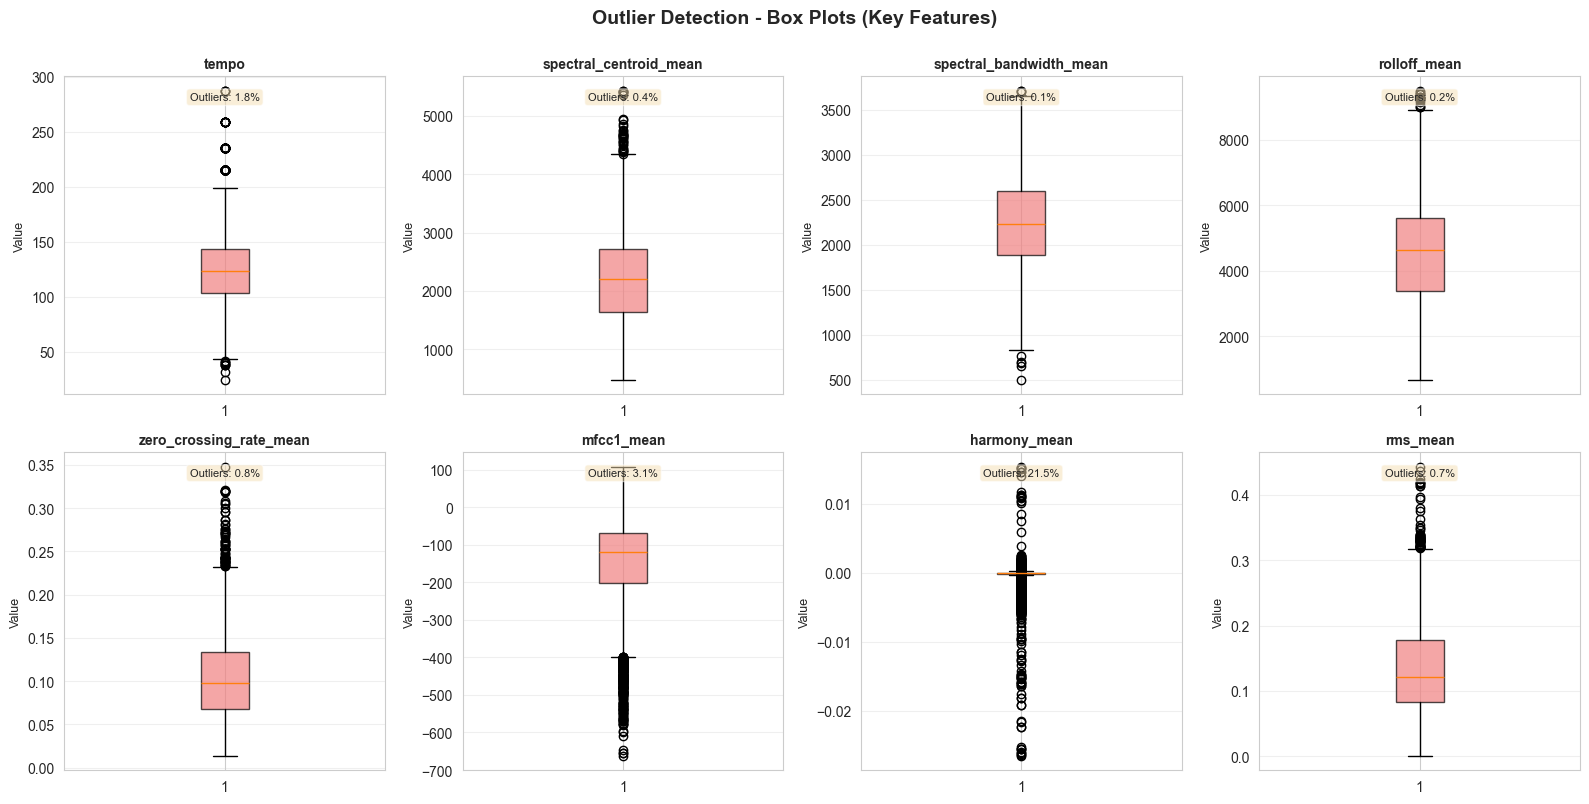

In [10]:
key_features = ['tempo', 'spectral_centroid_mean', 'spectral_bandwidth_mean', 
                'rolloff_mean', 'zero_crossing_rate_mean', 'mfcc1_mean', 
                'harmony_mean', 'rms_mean']

if len(key_features) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()
    
    for idx, feature in enumerate(key_features[:8]):
        # Remove NaN values for boxplot
        data = df[feature].dropna()
        
        box = axes[idx].boxplot(data, vert=True, patch_artist=True)
        box['boxes'][0].set_facecolor('lightcoral')
        box['boxes'][0].set_alpha(0.7)
        
        axes[idx].set_title(f'{feature}', fontsize=10, fontweight='bold')
        axes[idx].set_ylabel('Value', fontsize=9)
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Calculate outlier statistics
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
        outlier_pct = (len(outliers) / len(data)) * 100
        
        axes[idx].text(0.5, 0.95, f'Outliers: {outlier_pct:.1f}%', 
                      transform=axes[idx].transAxes, ha='center', va='top',
                      bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                      fontsize=8)
    
    plt.suptitle('Outlier Detection - Box Plots (Key Features)', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

Box plots help visualize outliers (points beyond whiskers)      
Decision: Keep outliers as they may be meaningful for genre classification.

### Outlier Detection Strategy:
There are multiple methods to detect outliers:
1. **IQR Method**: Interquartile Range (Q3 - Q1)
   - Outliers: Values < Q1 - 1.5*IQR or > Q3 + 1.5*IQR
2. **Z-Score Method**: Statistical measure of distance from mean
   - Outliers: |Z-score| > 3

For music features, some extreme values may be legitimate genre characteristics.
We will cap outliers using the IQR method (Winsorization) rather than removing them.

Analyzing outliers in 57 numeric features...

Features with more than 5% outliers (before capping):

               Feature  Outliers (%)
          harmony_mean         21.52
         perceptr_mean         14.03
zero_crossing_rate_var          9.08
               rms_var          9.05
            mfcc20_var          6.67
          perceptr_var          6.43
            mfcc19_var          6.37
            mfcc18_var          6.32
 spectral_centroid_var          5.92
            mfcc17_var          5.89

Outliers handled using IQR Winsorization method
  Total features with >5% outliers: 13


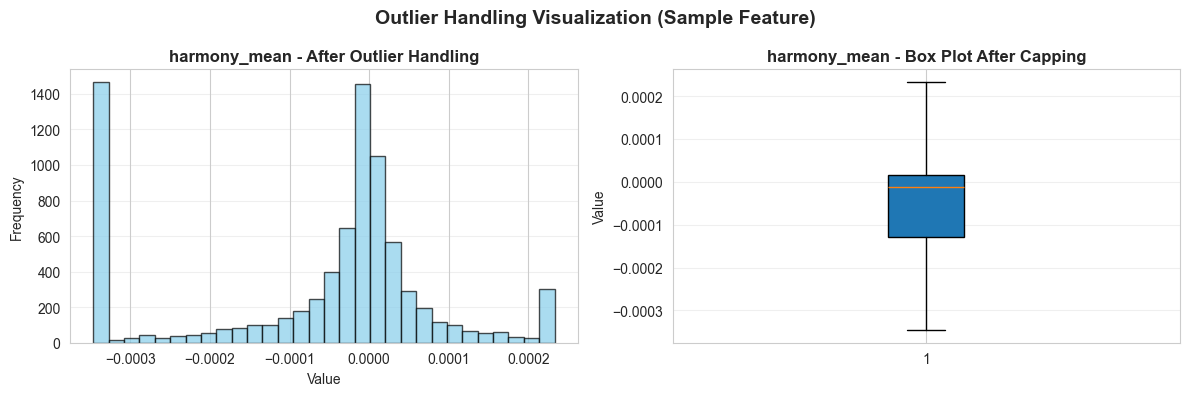

In [11]:
# Select numeric columns only (exclude filename, label)
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove non-feature metadata columns
for col in ['length']:
    if col in numeric_features:
        numeric_features.remove(col)

print(f"Analyzing outliers in {len(numeric_features)} numeric features...\n")

# IQR-based outlier detection and capping
outlier_summary = []

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers
    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    num_outliers = outlier_mask.sum()
    total = len(df)
    outlier_pct = (num_outliers / total) * 100
    
    # Cap outliers (Winsorization)
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    
    # Store result
    outlier_summary.append({
        'Feature': col,
        'Outliers (%)': round(outlier_pct, 2)
    })

# Convert to DataFrame
outlier_df = pd.DataFrame(outlier_summary)

# Filter for features with >5% outliers
outlier_df_filtered = outlier_df[outlier_df['Outliers (%)'] > 5].sort_values(
    by='Outliers (%)', ascending=False
)

# Display summary
if not outlier_df_filtered.empty:
    print("Features with more than 5% outliers (before capping):\n")
    print(outlier_df_filtered.head(10).to_string(index=False))
    print(f"\nOutliers handled using IQR Winsorization method")
    print(f"  Total features with >5% outliers: {len(outlier_df_filtered)}")
else:
    print("No features had more than 5% outliers detected.\n")


if len(numeric_features) > 0:
    sample_feature = outlier_df_filtered['Feature'].iloc[0] if not outlier_df_filtered.empty else numeric_features[0]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram after capping
    axes[0].hist(df[sample_feature], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0].set_title(f'{sample_feature} - After Outlier Handling', fontweight='bold')
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Frequency')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Boxplot after capping
    axes[1].boxplot(df[sample_feature], vert=True, patch_artist=True)
    axes[1].set_title(f'{sample_feature} - Box Plot After Capping', fontweight='bold')
    axes[1].set_ylabel('Value')
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.suptitle('Outlier Handling Visualization (Sample Feature)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


### 3.5 Label Encoding for Categorical Features

The genre labels are categorical strings. We need to encode them into numerical format for machine learning algorithms.


In [12]:
# Create LabelEncoder
label_encoder = LabelEncoder()

# Create a copy for encoding
df_preprocessed = df_cleaned.copy()

# Encode labels
df_preprocessed['label_encoded'] = label_encoder.fit_transform(df_preprocessed['label'])

# Display the mapping
print("\nGenre to Numerical Label Mapping:")
label_mapping = pd.DataFrame({
    'Genre': label_encoder.classes_,
    'Encoded_Value': range(len(label_encoder.classes_))
})
print(label_mapping.to_string(index=False))
label_mapping.to_csv(r'cleaned_data\label_mapping.csv')

# We will apply the same label encoding for the test_raw.csv for easier use in the future
test_df['label_encoded'] = label_encoder.transform(test_df['label'])
test_df.to_csv(r'cleaned_data\test_raw.csv')
df_preprocessed.to_csv(r'cleaned_data\train_raw.csv')


Genre to Numerical Label Mapping:
    Genre  Encoded_Value
    blues              0
classical              1
  country              2
    disco              3
   hiphop              4
     jazz              5
    metal              6
      pop              7
   reggae              8
     rock              9


### 3.6 Separating Features and Target

Before scaling, we need to separate our features (X) from the target variable (y) and exclude non-numerical columns like filename.


In [13]:
# Exclude non-numerical columns and the encoded label
columns_to_exclude = ['filename', 'label', 'label_encoded']
X = df_preprocessed.drop(columns=columns_to_exclude, axis=1)

# Target variable
y = df_preprocessed['label_encoded']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (7992, 58)
Target shape: (7992,)


### 3.7 Feature Scaling

Machine learning algorithms perform better when features are on a similar scale. We'll use StandardScaler to normalize features to have zero mean and unit variance.

**Why scaling?**
- Many ML algorithms are sensitive to feature scales
- Prevents features with larger scales from dominating the model
- Speeds up convergence in optimization algorithms


In [14]:
# Create scaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("\nFeatures scaled successfully!")
print(f"\nScaled features shape: {X_scaled_df.shape}")


Features scaled successfully!

Scaled features shape: (7992, 58)


### After Scaling - Statistical summary

In [15]:
# Display statistical summary of scaled features
print("\nMean and Std of first 5 scaled features:")
stats_df = pd.DataFrame({
    'Mean': X_scaled_df.iloc[:, :5].mean(),
    'Std': X_scaled_df.iloc[:, :5].std()
})
print(stats_df)

print("\nAs expected, scaled features have mean ≈ 0 and std ≈ 1")



Mean and Std of first 5 scaled features:
                          Mean       Std
length            0.000000e+00  0.000000
chroma_stft_mean -5.334405e-18  1.000063
chroma_stft_var  -1.436733e-15  1.000063
rms_mean         -7.245900e-16  1.000063
rms_var          -8.535048e-17  1.000063

As expected, scaled features have mean ≈ 0 and std ≈ 1


### 3.8 Dimensionality Reduction

We will apply two different dimensionality reduction techniques to evaluate which provides better results:

1. **Principal Component Analysis (PCA)**  
   PCA will be performed until we achieve **95% of the total variance** in the dataset.  
   This helps reduce dimensionality while retaining most of the important information.

2. **Linear Discriminant Analysis (LDA)**  
   LDA will be used to maximize **class separability** by finding feature combinations that best distinguish different genres.


Original number of features: 58
Number of components after PCA (95% variance): 39
Variance retained: 95.30%

Explained variance by first 10 components:
  PC1: 20.10% (Cumulative: 20.10%)
  PC2: 13.52% (Cumulative: 33.61%)
  PC3: 10.34% (Cumulative: 43.96%)
  PC4: 6.64% (Cumulative: 50.60%)
  PC5: 4.41% (Cumulative: 55.00%)
  PC6: 3.66% (Cumulative: 58.66%)
  PC7: 2.94% (Cumulative: 61.61%)
  PC8: 2.64% (Cumulative: 64.25%)
  PC9: 2.49% (Cumulative: 66.74%)
  PC10: 2.10% (Cumulative: 68.84%)



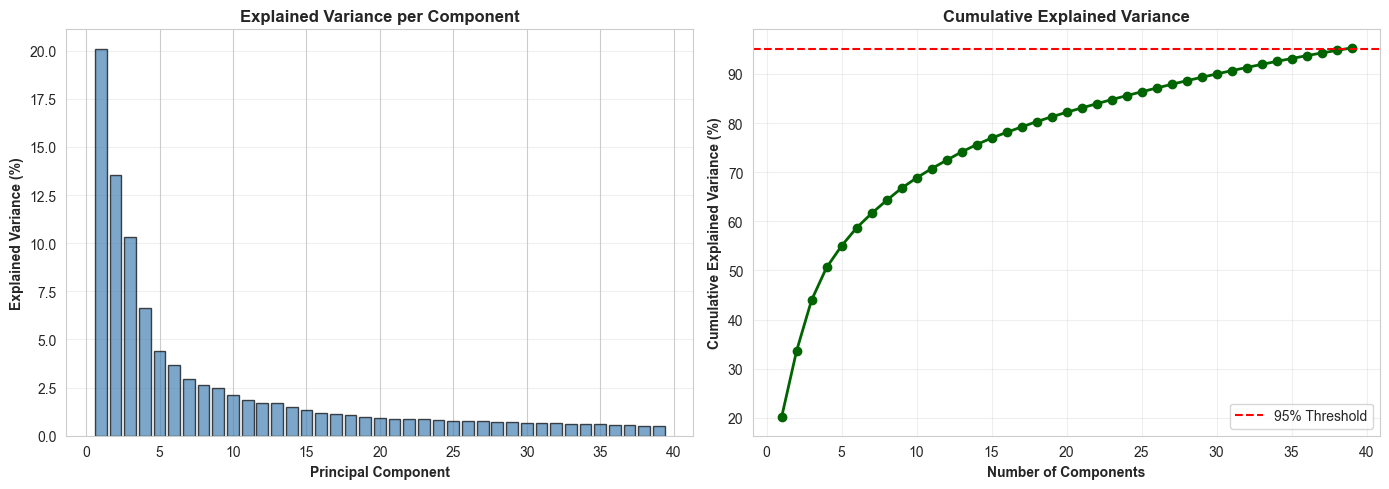

PCA transformation completed successfully
Dimensionality reduced from 58 to 39 features



In [16]:
from sklearn.decomposition import PCA

# Apply PCA with 95% variance retention
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Original number of features: {X_scaled.shape[1]}")
print(f"Number of components after PCA (95% variance): {X_pca.shape[1]}")
print(f"Variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print()

# Display explained variance per component
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Explained variance by first 10 components:")
for i in range(min(10, len(explained_variance))):
    print(f"  PC{i+1}: {explained_variance[i]*100:.2f}% "
          f"(Cumulative: {cumulative_variance[i]*100:.2f}%)")
print()

# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual explained variance
axes[0].bar(range(1, len(explained_variance)+1), explained_variance*100, 
            color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Principal Component', fontweight='bold')
axes[0].set_ylabel('Explained Variance (%)', fontweight='bold')
axes[0].set_title('Explained Variance per Component', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Cumulative explained variance
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance*100, 
             marker='o', color='darkgreen', linewidth=2, markersize=6)
axes[1].axhline(y=95, color='red', linestyle='--', label='95% Threshold')
axes[1].set_xlabel('Number of Components', fontweight='bold')
axes[1].set_ylabel('Cumulative Explained Variance (%)', fontweight='bold')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("PCA transformation completed successfully")
print(f"Dimensionality reduced from {X_scaled.shape[1]} to {X_pca.shape[1]} features")
print()

### LDA Implementation Details:
LDA requires labeled data and finds directions that:
1. Maximize between-class variance
2. Minimize within-class variance

Maximum components = n_classes - 1 = 10 - 1 = 9 components

Number of genres (classes): 10
Maximum LDA components: 9

Original number of features: 58
Number of components after LDA: 9
Variance retained: 100.00%

Explained variance by all LDA components:
  LD1: 45.50% (Cumulative: 45.50%)
  LD2: 21.73% (Cumulative: 67.23%)
  LD3: 10.13% (Cumulative: 77.36%)
  LD4: 8.14% (Cumulative: 85.50%)
  LD5: 4.95% (Cumulative: 90.45%)
  LD6: 3.57% (Cumulative: 94.02%)
  LD7: 3.34% (Cumulative: 97.37%)
  LD8: 1.95% (Cumulative: 99.32%)
  LD9: 0.68% (Cumulative: 100.00%)



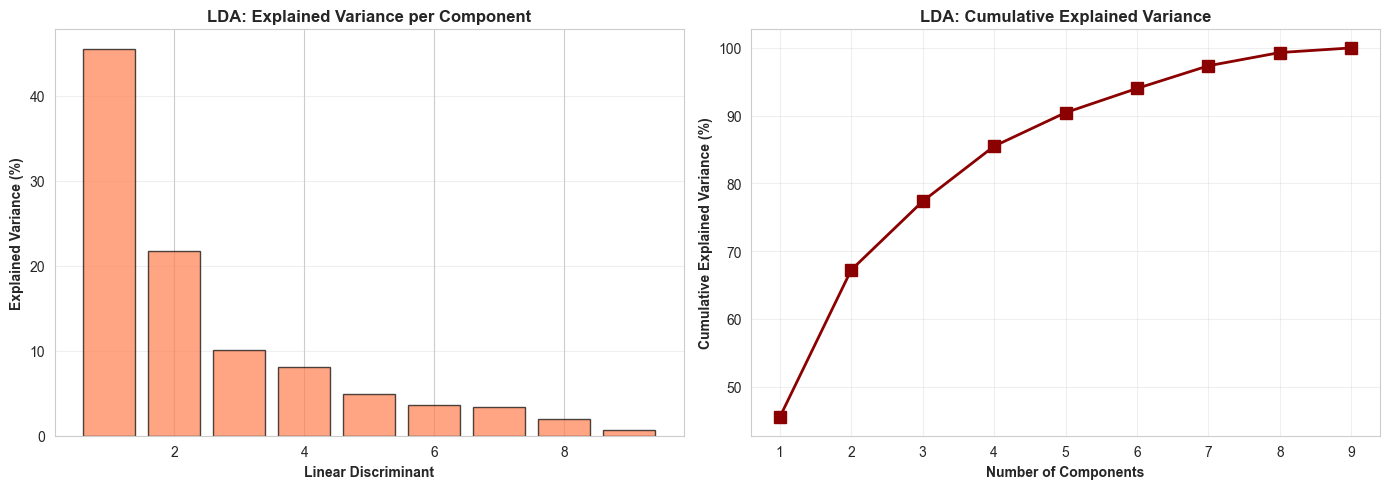

LDA transformation completed successfully
Dimensionality reduced from 58 to 9 features



In [17]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Apply LDA (maximum components = n_classes - 1)
n_components_lda = len(np.unique(y)) - 1
print(f"Number of genres (classes): {len(np.unique(y))}")
print(f"Maximum LDA components: {n_components_lda}")
print()

lda = LinearDiscriminantAnalysis(n_components=n_components_lda)
X_lda = lda.fit_transform(X_scaled, y)

print(f"Original number of features: {X_scaled.shape[1]}")
print(f"Number of components after LDA: {X_lda.shape[1]}")
print(f"Variance retained: {lda.explained_variance_ratio_.sum()*100:.2f}%")
print()

# Display explained variance per component
explained_variance_lda = lda.explained_variance_ratio_
cumulative_variance_lda = np.cumsum(explained_variance_lda)

print("Explained variance by all LDA components:")
for i in range(len(explained_variance_lda)):
    print(f"  LD{i+1}: {explained_variance_lda[i]*100:.2f}% "
          f"(Cumulative: {cumulative_variance_lda[i]*100:.2f}%)")
print()

# Visualize LDA explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual explained variance
axes[0].bar(range(1, len(explained_variance_lda)+1), explained_variance_lda*100, 
            color='coral', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Linear Discriminant', fontweight='bold')
axes[0].set_ylabel('Explained Variance (%)', fontweight='bold')
axes[0].set_title('LDA: Explained Variance per Component', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Cumulative explained variance
axes[1].plot(range(1, len(cumulative_variance_lda)+1), cumulative_variance_lda*100, 
             marker='s', color='darkred', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Components', fontweight='bold')
axes[1].set_ylabel('Cumulative Explained Variance (%)', fontweight='bold')
axes[1].set_title('LDA: Cumulative Explained Variance', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("LDA transformation completed successfully")
print(f"Dimensionality reduced from {X_scaled.shape[1]} to {X_lda.shape[1]} features")
print()


### PCA vs LDA comparision

In [18]:
comparison_data = {
    'Metric': ['Method Type', 'Components', 'Total Variance', 'Uses Labels'],
    'PCA': ['Unsupervised', X_pca.shape[1], f"{pca.explained_variance_ratio_.sum()*100:.2f}%", 'No'],
    'LDA': ['Supervised', X_lda.shape[1], f"{lda.explained_variance_ratio_.sum()*100:.2f}%", 'Yes']
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))
print()

        Metric          PCA        LDA
   Method Type Unsupervised Supervised
    Components           39          9
Total Variance       95.30%    100.00%
   Uses Labels           No        Yes



### 3.7 Optional: Feature Binning/Binarization
For some applications, binning continuous features can help:
- Reduce noise and outliers
- Create categorical features from continuous ones
- Improve model interpretability

However, for music genre classification with PCA-transformed features,
binning is typically NOT recommended as it may lose important continuous information.

We will SKIP binning for this project to preserve the rich continuous feature space.

### 3.8 Final Preprocessed Data after preprocessing

In [19]:
# Create final preprocessed dataset
df_preprocessed_pca = pd.DataFrame(
    X_pca, 
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])],
    index=X.index   # keep same index as original features
)


df_preprocessed_pca['genre_encoded'] = y.values

print("Final preprocessed dataset preview:")
print(df_preprocessed_pca.shape)
df_preprocessed_pca.sample(5)


Final preprocessed dataset preview:
(7992, 40)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,genre_encoded
8940,1.519967,-0.084185,-2.118952,-1.543497,-0.583385,-0.514363,-0.110758,-0.792896,0.847966,-0.697641,...,0.091141,-0.357963,0.040808,-0.193658,0.277550,-0.205204,1.591549,0.034433,0.431198,8
9265,-1.783427,1.944901,-2.479304,1.258334,-0.029238,-1.266896,1.289845,1.164987,0.474886,0.283176,...,0.065485,0.559972,0.153216,0.461366,0.395309,0.256808,-0.034072,0.142488,0.531377,9
3642,1.184164,-0.285995,3.587017,-1.606035,2.045691,-1.721588,-0.288941,-2.167065,0.110587,2.646073,...,0.550000,-0.392744,-1.077183,-0.199803,0.163372,-0.247906,0.165850,-0.025186,0.523475,3
1990,-4.810496,-1.051296,0.004214,0.983447,4.004724,-0.733298,1.888551,0.235940,1.143438,-1.402361,...,-0.262248,-0.670755,-0.323289,0.861745,-0.838595,-0.037697,-1.841762,0.304678,-0.657439,1
9877,-1.296443,-0.532757,2.774058,0.329379,-0.634141,-1.041636,-1.054278,0.316641,-1.825834,1.694613,...,0.705305,0.505225,-0.880545,0.386026,-0.585641,-0.364119,0.381634,-1.004957,0.857198,9


In [20]:
df_preprocessed_lda = pd.DataFrame(
    X_lda, 
    columns=[f'LD{i+1}' for i in range(X_lda.shape[1])],
    index=X.index   # keep same index as original features
)

df_preprocessed_lda['genre_encoded'] = y.values

print("Final preprocessed dataset preview:")
print(df_preprocessed_lda.shape)
df_preprocessed_lda.sample(5)

Final preprocessed dataset preview:
(7992, 10)


,LD1,LD2,LD3,LD4,LD5,LD6,LD7,LD8,LD9,genre_encoded
426,-0.570028,-1.687747,0.446664,0.941481,1.718364,0.228289,0.423475,-1.428216,-0.638890,0
2193,2.008371,0.487170,0.790950,-0.040559,-1.437129,-1.410980,-0.397101,0.433627,-1.499025,2
7559,-2.024220,3.747994,-0.455812,-1.016476,1.806614,1.398999,-1.642227,-1.378525,2.689901,7
2422,-0.789389,0.833365,0.280941,1.090172,-1.146482,-0.295642,-0.628764,0.950209,0.422261,2
2417,-0.974023,0.401665,0.659972,1.554926,-0.866935,-0.214714,-0.090398,0.912712,0.368409,2


In [21]:
X_scaled_df['genre_encoded'] = y
print("Final preprocessed dataset preview:")
print(X_scaled_df.shape)

X_scaled_df.sample(5)

Final preprocessed dataset preview:
(7992, 59)


,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,genre_encoded
5226,0.0,-1.728455,0.157407,-0.281923,-0.475849,-0.709284,-0.264060,-0.622177,-0.133211,-0.642977,...,-0.002688,-0.438680,-0.536611,-0.232821,-0.540203,-1.516862,-0.283146,-1.330335,0.390134,5
3251,0.0,0.155492,0.022037,-0.486743,0.177479,0.443686,0.245303,0.651501,0.570980,0.462551,...,-0.186452,-0.077678,-0.882120,-0.246964,-0.713950,0.889580,-0.232323,0.198080,0.095933,3
591,0.0,0.395541,-0.149552,0.563728,0.298765,-0.064161,-0.511448,-0.312417,-0.964925,-0.206043,...,-0.143885,-0.161424,-0.277418,0.631047,0.257311,-0.651491,-0.017329,0.576530,-0.445424,0
948,0.0,-0.327695,0.828938,-0.045955,0.783697,-1.714218,-0.587563,-1.447011,0.443311,-1.685147,...,0.325554,-0.263892,0.464373,-0.451111,-0.222284,0.723579,0.288796,0.353352,-0.626333,0
4300,0.0,1.730024,-1.575406,0.885152,-0.463454,2.107917,-0.270950,1.799886,-0.768798,1.910403,...,-1.030191,0.274629,-1.065483,-0.400851,-0.968326,-0.435692,-0.967972,-0.256077,-0.933747,4


In [22]:
import os

# Create the folder if it doesn't exist
os.makedirs("cleaned_data", exist_ok=True)

# Save the PCA-transformed data
df_preprocessed_pca.to_csv(r"cleaned_data\PCA_Processed_Data.csv", index=False)
print("PCA data successfully saved in 'cleaned_data/PCA_Processed_Data.csv'")

df_preprocessed_lda.to_csv(r"cleaned_data\LDA_Processed_Data.csv", index=False)
print("LDA data successfully saved in 'cleaned_data/LDA_Processed_Data.csv'")

X_scaled_df.to_csv(r"cleaned_data\Processed_Data.csv", index=False)
print("Processed data successfully saved in 'cleaned_data/Processed_Data.csv'")

PCA data successfully saved in 'cleaned_data/PCA_Processed_Data.csv'
LDA data successfully saved in 'cleaned_data/LDA_Processed_Data.csv'
Processed data successfully saved in 'cleaned_data/Processed_Data.csv'


---

## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand patterns, relationships, and distributions in our data. We'll perform:

1. **Univariate Analysis**: Examine individual feature distributions
2. **Bivariate Analysis**: Explore relationships between features and target variable
3. **Correlation Analysis**: Identify feature correlations


In [23]:
X_analysis = X_scaled_df.copy() 
X_analysis['genre'] = label_encoder.inverse_transform(y)

### 4.1. Univariate Analysis – Distribution of Top Features

- This step explores the **distribution of individual audio features** across all tracks.  
- Helps identify **skewed data**, **outliers**, and **dominant feature ranges** such as MFCCs, spectral centroid, and tempo.  
- Histograms with kernel density estimates (KDE) provide insight into how each feature varies throughout the dataset.

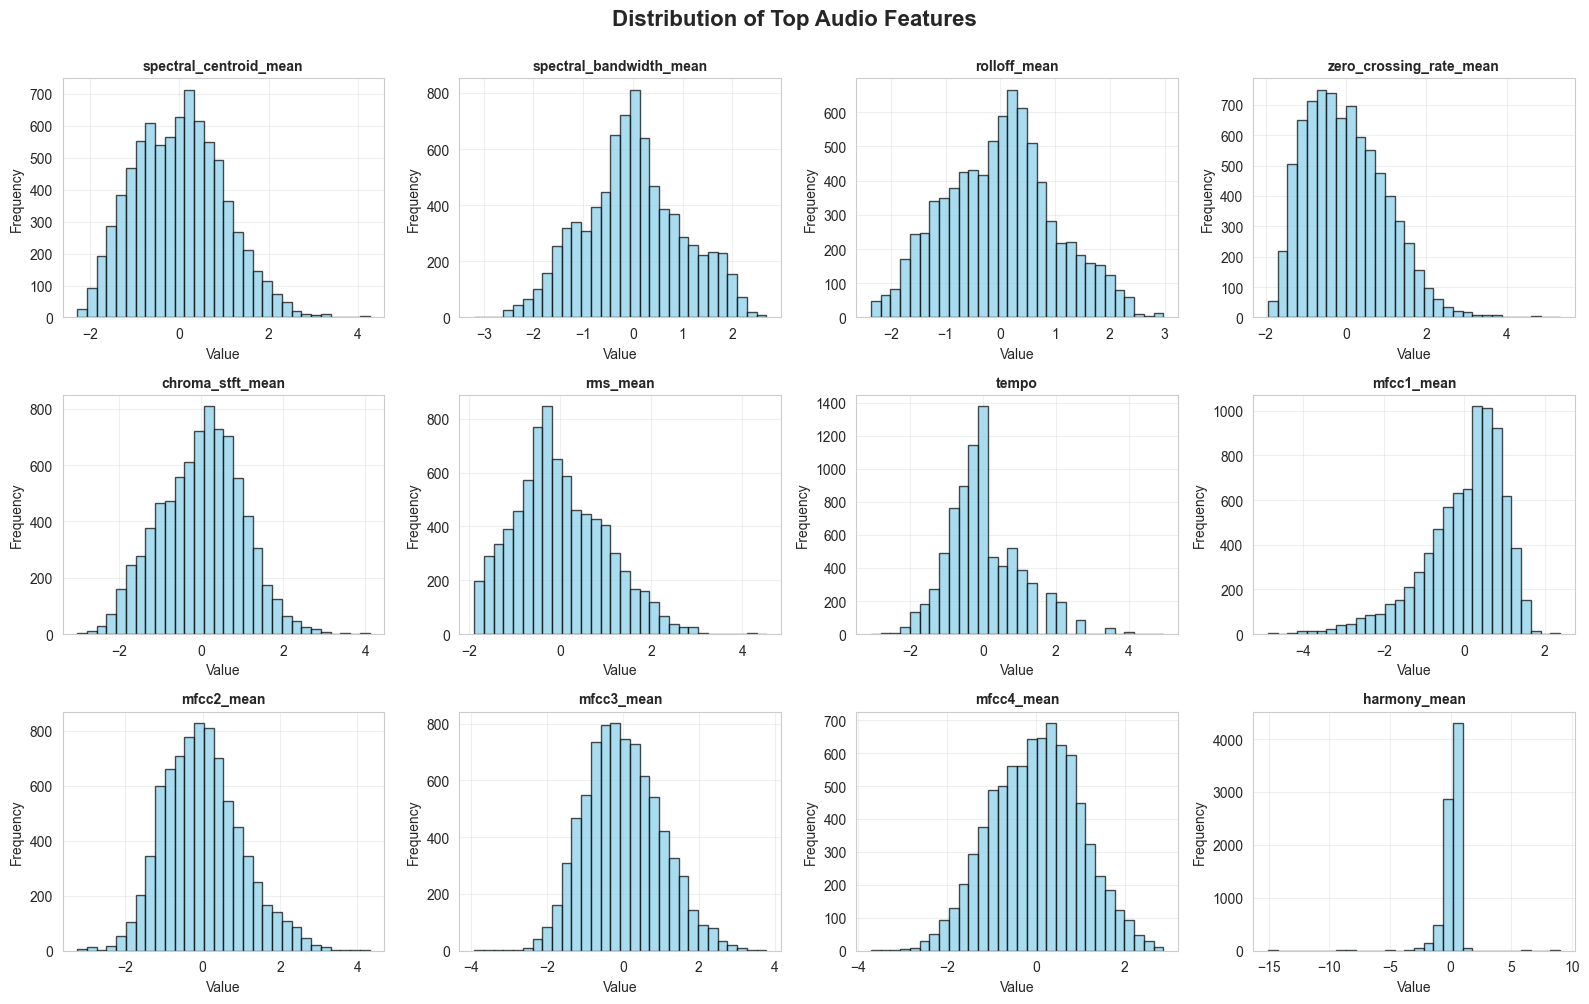

In [24]:

top_features = [
    'spectral_centroid_mean',
    'spectral_bandwidth_mean',
    'rolloff_mean',
    'zero_crossing_rate_mean',
    'chroma_stft_mean',
    'rms_mean',
    'tempo',
    'mfcc1_mean',
    'mfcc2_mean',
    'mfcc3_mean',
    'mfcc4_mean',
    'harmony_mean'
]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Distribution of Top Audio Features', fontsize=16, fontweight='bold', y=1.00)

for idx, feature in enumerate(top_features):
    ax = axes[idx // 4, idx % 4]
    X_analysis[feature].hist(bins=30, ax=ax, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_title(feature, fontsize=10, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 4.2. Bivariate Analysis – Feature vs Genre

- Examines how each selected **feature varies across different genres**.  
- **Boxplots** show median, quartiles, and potential outliers, making it easy to spot which features effectively separate genres.  
- Useful for detecting **overlapping genres**, such as Rock–Metal or Jazz–Blues.


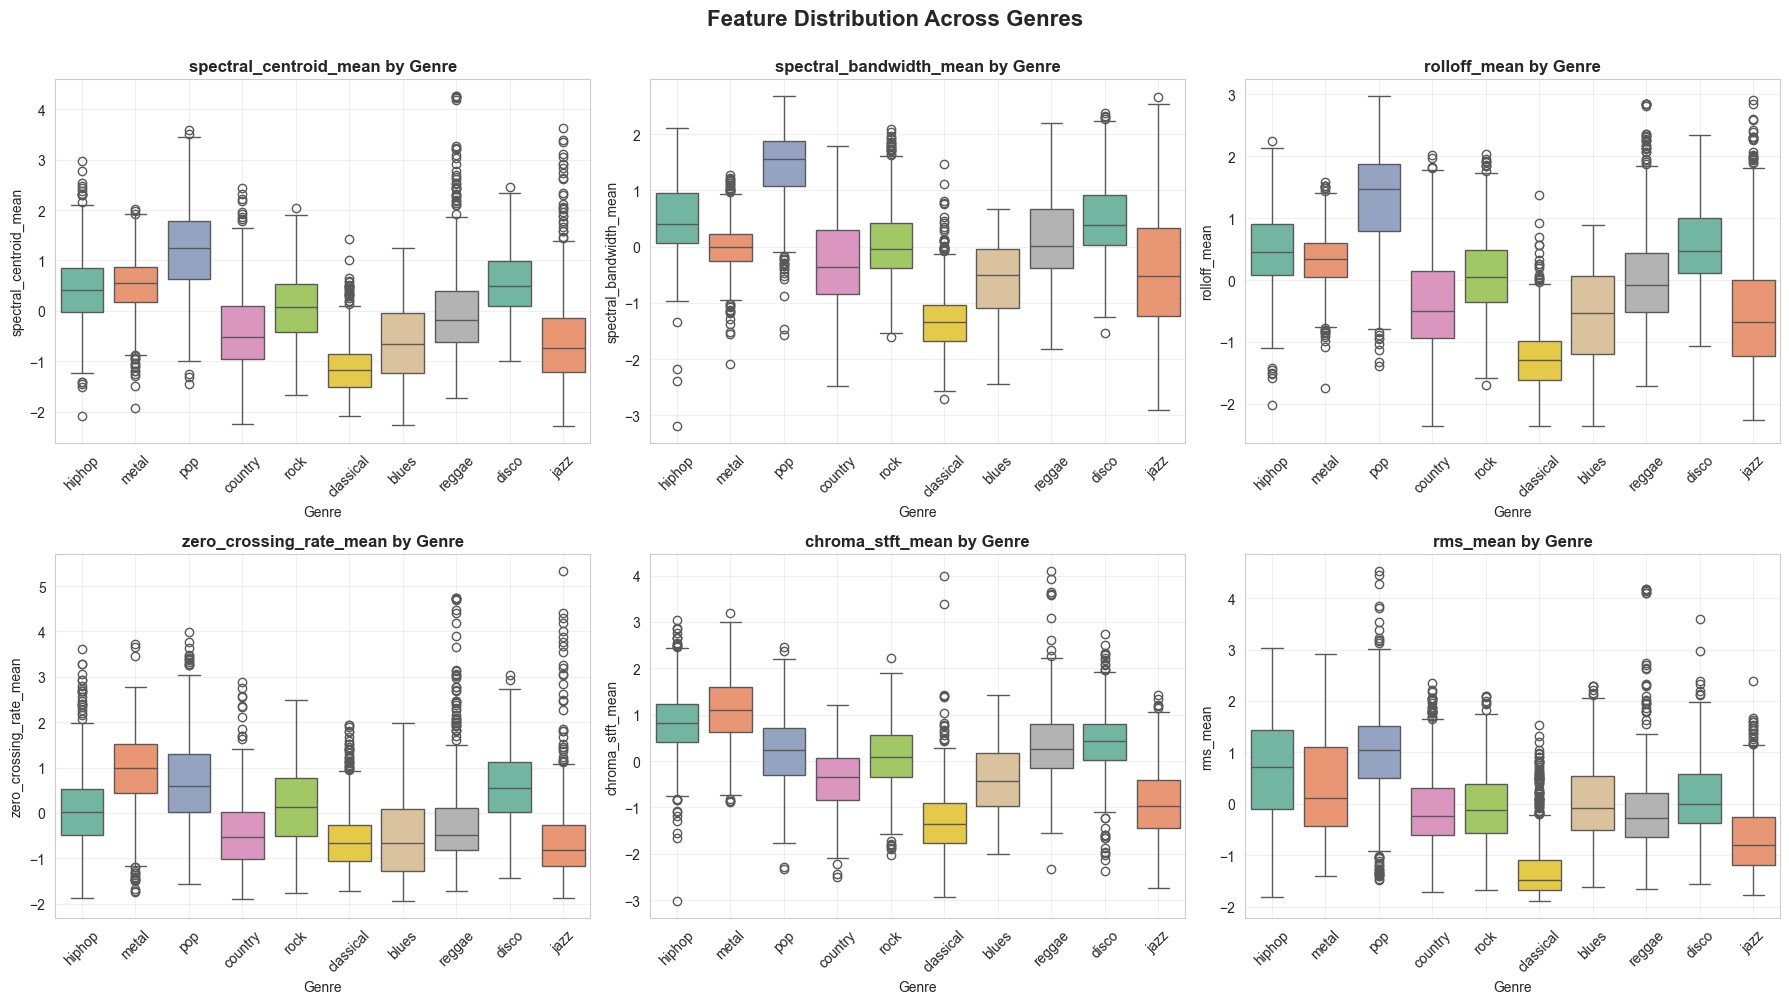

In [25]:
# Select top 6 features for detailed boxplot analysis
top_6_features = top_features[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Feature Distribution Across Genres', fontsize=16, fontweight='bold', y=1.00)

for idx, feature in enumerate(top_6_features):
    ax = axes[idx // 3, idx % 3]
    sns.boxplot(data=X_analysis, x='genre', y=feature, ax=ax, palette='Set2')
    ax.set_title(f'{feature} by Genre', fontsize=12, fontweight='bold')
    ax.set_xlabel('Genre', fontsize=10)
    ax.set_ylabel(feature, fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4.3. Multivariate Analysis – Pairplot of Top Features

- Explores **relationships between multiple features simultaneously**.  
- Scatter patterns reveal **cluster tendencies** of genres and potential feature interactions.  
- Helps detect **feature groupings** and whether genres form distinct regions in feature space.

<Figure size 1400x1200 with 0 Axes>

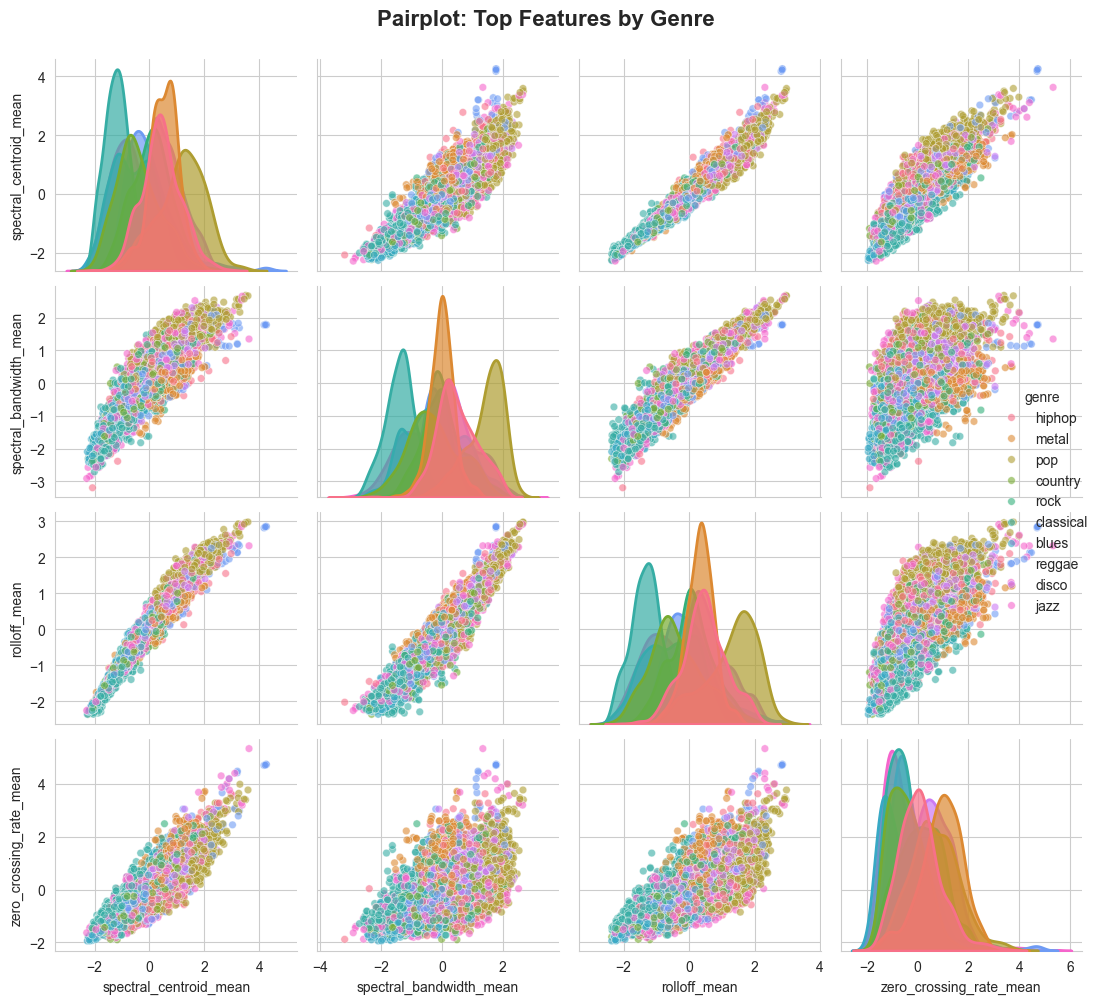

In [26]:

# Select top 4 features for pairplot (to keep it readable)
top_4_features = top_features[:4]
pairplot_data = X_analysis[top_4_features + ['genre']]

plt.figure(figsize=(14, 12))
pairplot = sns.pairplot(pairplot_data, hue='genre', palette='husl', 
                         diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30},
                         diag_kws={'alpha': 0.7, 'linewidth': 2})
pairplot.fig.suptitle('Pairplot: Top Features by Genre', 
                      fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 4.4. Correlation & Redundancy – Feature Heatmap

- Shows how strongly different features are correlated with each other.  
- High correlations indicate **redundancy**, meaning some features may convey similar information (e.g., spectral rolloff and centroid).  
- Identifying such pairs helps in **feature selection** and **dimensionality reduction**.

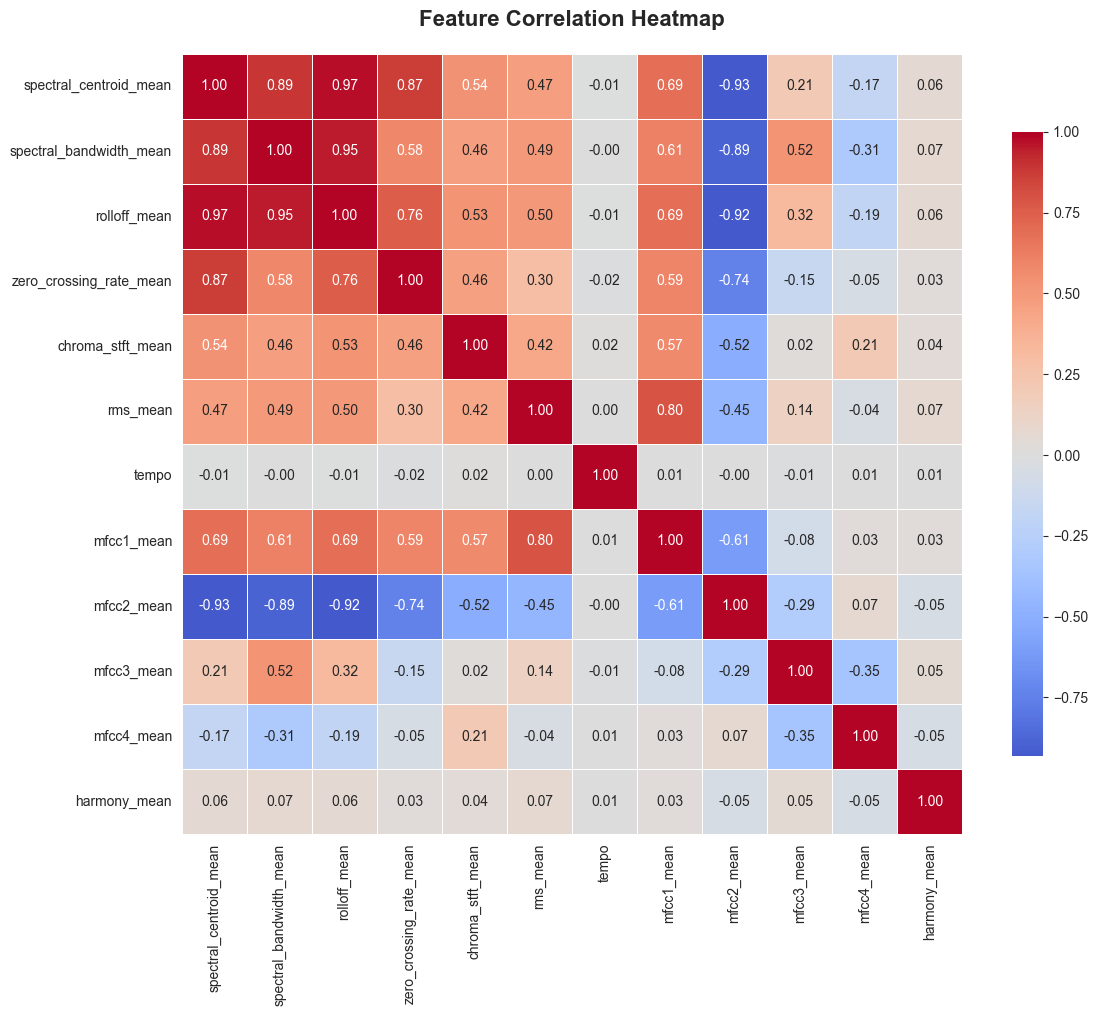

In [27]:
feature_cols = top_features
correlation_matrix = X_analysis[feature_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [28]:
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.8:
            high_corr_pairs.append((correlation_matrix.columns[i],
                                    correlation_matrix.columns[j],
                                    corr_value))

if high_corr_pairs:
    print("\nHighly Correlated Feature Pairs (|r| > 0.8):")
    for f1, f2, r in high_corr_pairs:
        print(f" {f1} <-> {f2} -> r = {r:.2f}")
else:
    print("\nNo highly correlated feature pairs found (|r| > 0.8).")


Highly Correlated Feature Pairs (|r| > 0.8):
 spectral_centroid_mean <-> spectral_bandwidth_mean -> r = 0.89
 spectral_centroid_mean <-> rolloff_mean -> r = 0.97
 spectral_centroid_mean <-> zero_crossing_rate_mean -> r = 0.87
 spectral_centroid_mean <-> mfcc2_mean -> r = -0.93
 spectral_bandwidth_mean <-> rolloff_mean -> r = 0.95
 spectral_bandwidth_mean <-> mfcc2_mean -> r = -0.89
 rolloff_mean <-> mfcc2_mean -> r = -0.92


### 4.5. Audio-Specific EDA – Mean Feature Comparison Across Genres

- Focuses on key **audio descriptors** like MFCCs, spectral centroid, chroma, tempo, and zero-crossing rate.  
- Compares the **average feature values** for each genre to highlight distinct acoustic profiles.  
- Useful for understanding which characteristics dominate certain genres (e.g., higher tempo for Disco, lower spectral centroid for Classical).

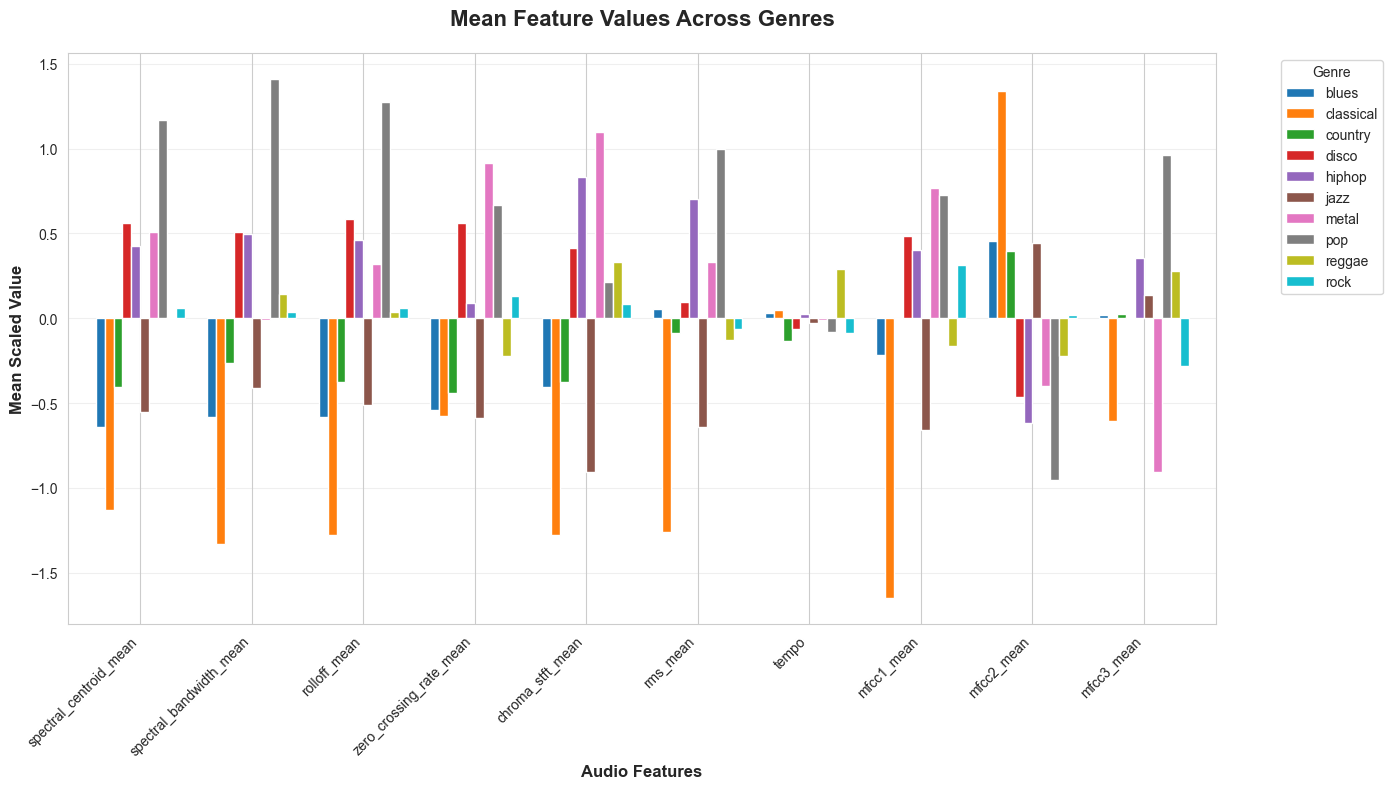

In [29]:
# Calculate mean features per genre
genre_means = X_analysis.groupby('genre')[feature_cols].mean()

# Plot top 10 features
top_10_features = feature_cols[:10]
genre_means_subset = genre_means[top_10_features]

fig, ax = plt.subplots(figsize=(14, 8))
genre_means_subset.T.plot(kind='bar', ax=ax, width=0.8, colormap='tab10')
ax.set_title('Mean Feature Values Across Genres', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Audio Features', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Scaled Value', fontsize=12, fontweight='bold')
ax.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

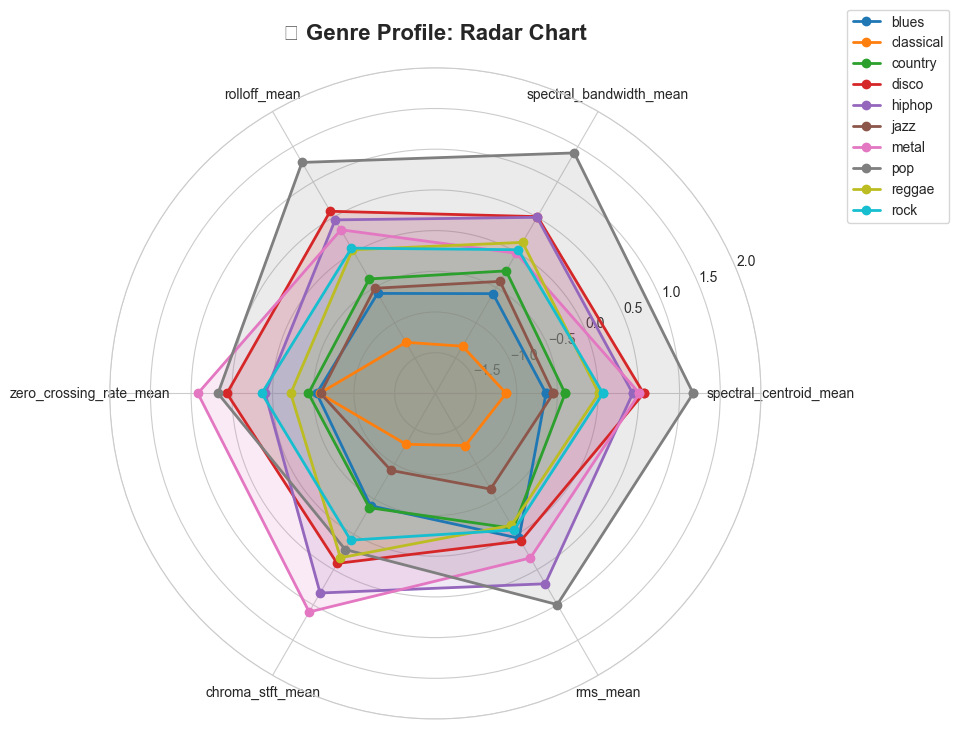

In [30]:
# Radar chart for genre comparison
from math import pi

genres = genre_means.index.tolist()
features_for_radar = top_features[:6]  # Use top 6 features
num_features = len(features_for_radar)

angles = [n / float(num_features) * 2 * pi for n in range(num_features)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
colors = plt.cm.tab10(np.linspace(0, 1, len(genres)))

for idx, genre in enumerate(genres):
    values = genre_means.loc[genre, features_for_radar].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=genre, color=colors[idx])
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features_for_radar, size=10)
ax.set_ylim(-2, 2)
ax.set_title('🎵 Genre Profile: Radar Chart', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)
plt.tight_layout()
plt.show()

### 4.6. Genre Similarity – Cosine Similarity Heatmap

- Measures **how similar genres are** based on their average audio feature vectors.  
- Uses **cosine similarity** to quantify closeness — higher values mean more acoustically similar genres.  
- Reveals natural relationships like **Rock–Metal** or **Jazz–Blues** overlap.

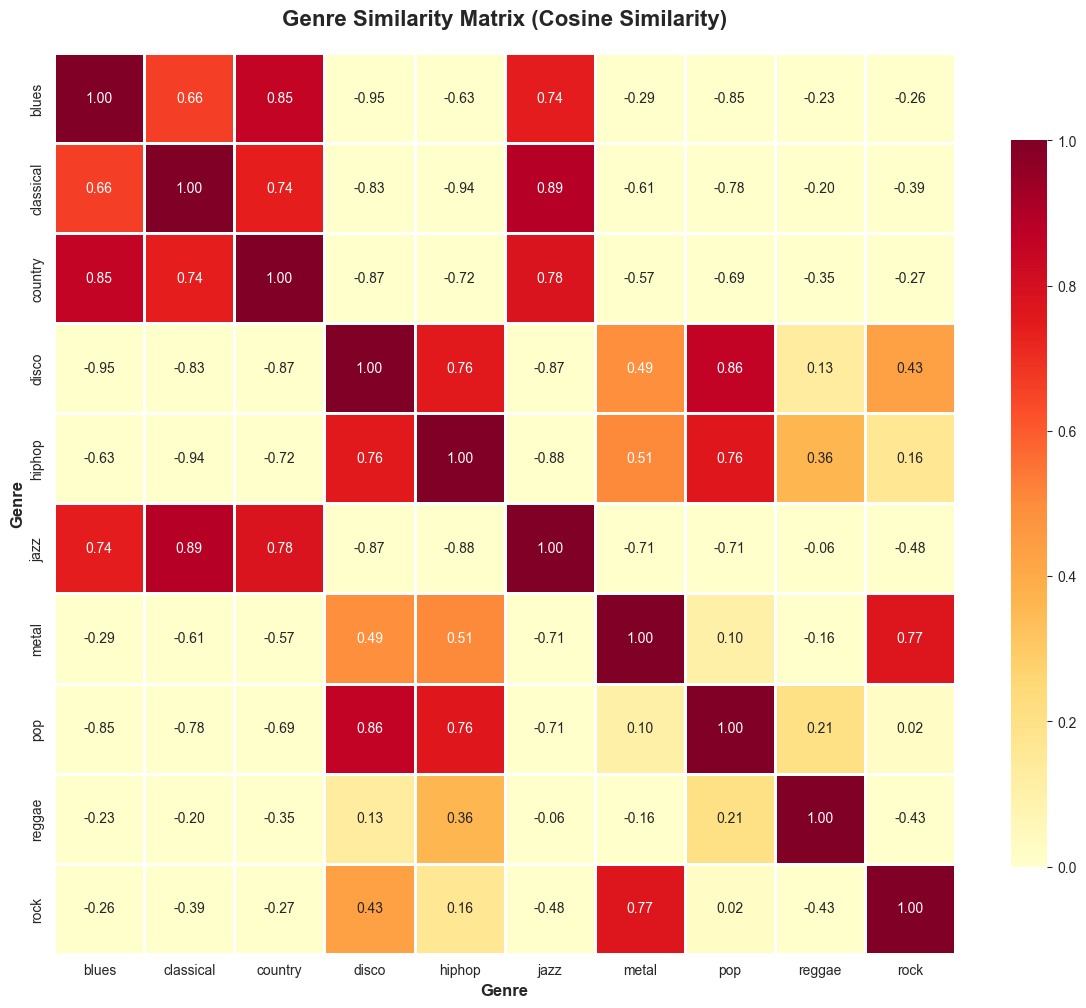


Genre Similarity Insights:

 Most Similar Genre Pairs:
  Genre 1 Genre 2  Similarity
classical    jazz    0.889301
    disco     pop    0.859128
    blues country    0.854013
  country    jazz    0.779646
    metal    rock    0.766148

 Least Similar Genre Pairs:
  Genre 1 Genre 2  Similarity
  country   disco   -0.869034
    disco    jazz   -0.872678
   hiphop    jazz   -0.884842
classical  hiphop   -0.939547
    blues   disco   -0.951278


In [31]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate cosine similarity between genres based on mean feature vectors
similarity_matrix = cosine_similarity(genre_means)
similarity_df = pd.DataFrame(similarity_matrix, 
                             index=genre_means.index, 
                             columns=genre_means.index)

plt.figure(figsize=(12, 10))
sns.heatmap(similarity_df, annot=True, fmt='.2f', cmap='YlOrRd', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=0, vmax=1)
plt.title('Genre Similarity Matrix (Cosine Similarity)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Genre', fontsize=12, fontweight='bold')
plt.ylabel('Genre', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Find most and least similar genre pairs
print("\nGenre Similarity Insights:")

similarity_pairs = []
for i in range(len(similarity_df.index)):
    for j in range(i+1, len(similarity_df.columns)):
        similarity_pairs.append({
            'Genre 1': similarity_df.index[i],
            'Genre 2': similarity_df.columns[j],
            'Similarity': similarity_df.iloc[i, j]
        })

similarity_pairs_df = pd.DataFrame(similarity_pairs).sort_values('Similarity', ascending=False)

print("\n Most Similar Genre Pairs:")
print(similarity_pairs_df.head(5).to_string(index=False))

print("\n Least Similar Genre Pairs:")
print(similarity_pairs_df.tail(5).to_string(index=False))

### 4.7 Violin Plot Interpretation – Tempo Across Genres

A **violin plot** visualizes both the **distribution** (density) and **summary statistics** (median and quartiles) of a numerical feature.  
It shows where tempo values concentrate and how they vary across different genres.

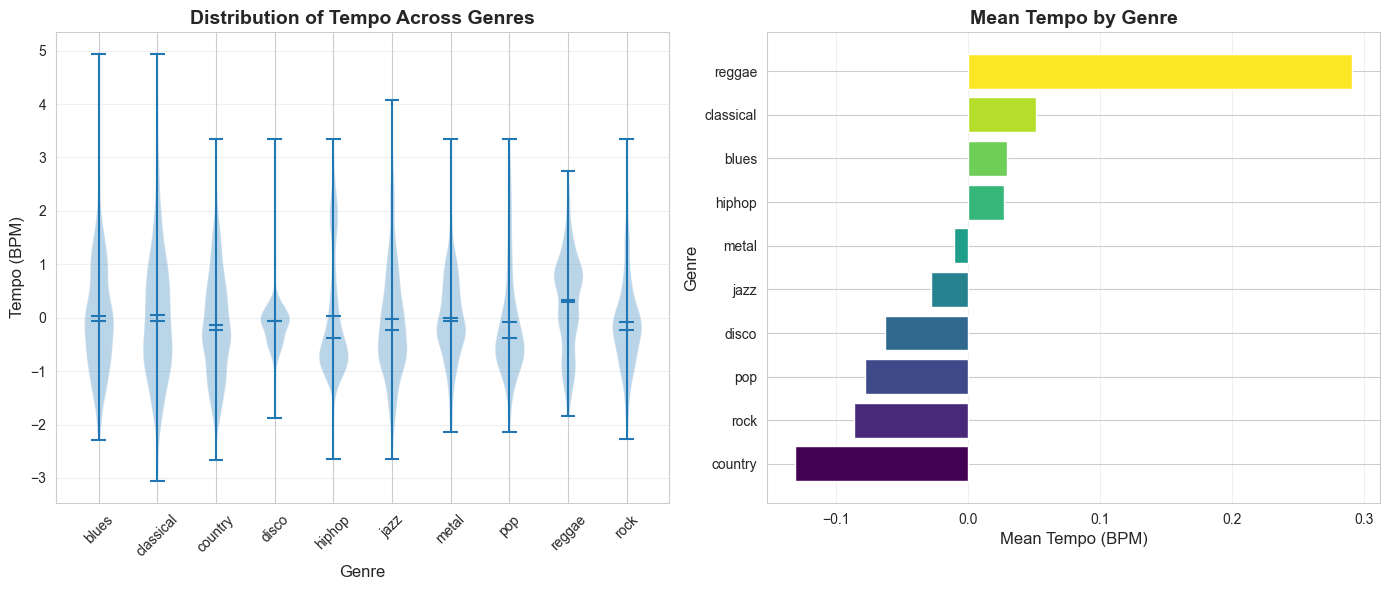


✓ Tempo analysis shows clear differences between genres (e.g., Classical vs Metal).


In [32]:
# Distribution of tempo by genre
plt.figure(figsize=(14, 6))

# Violin plot for tempo distribution
plt.subplot(1, 2, 1)
tempo_data = []
genre_list = []
for genre in sorted(X_analysis['genre'].unique()):
    tempo_values = X_analysis[X_analysis['genre'] == genre]['tempo'].values
    tempo_data.append(tempo_values)
    genre_list.append(genre)

parts = plt.violinplot(tempo_data, positions=range(len(genre_list)), 
                       showmeans=True, showmedians=True)
plt.xticks(range(len(genre_list)), genre_list, rotation=45)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Tempo (BPM)', fontsize=12)
plt.title('Distribution of Tempo Across Genres', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Mean tempo comparison
plt.subplot(1, 2, 2)
mean_tempo = X_analysis.groupby('genre')['tempo'].mean().sort_values()
colors = plt.cm.viridis(np.linspace(0, 1, len(mean_tempo)))
plt.barh(mean_tempo.index, mean_tempo.values, color=colors)
plt.xlabel('Mean Tempo (BPM)', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.title('Mean Tempo by Genre', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Tempo analysis shows clear differences between genres (e.g., Classical vs Metal).")


#### Insights from the Tempo Violin Plot

- **Disco / Pop / Rock** → Narrow, centered violins around moderate to high BPM (≈ 120–140).  
     Indicate steady, danceable beats with consistent rhythm.

- **Classical / Blues / Jazz** → Broad, lower-centered violins.  
     Represent slower and more variable tempos, often lacking a strong percussive pulse.

- **Metal / Country / Hip-hop** → Slightly higher and wider distributions.  
     Reflect faster, energetic tracks with more rhythmic intensity.

- **Reggae** → Mid-range, moderately narrow violin shape.  
     Suggests a steady, relaxed tempo typical of laid-back rhythmic grooves.

---
### Summary and Next Steps

The dataset has been successfully preprocessed and is ready for model training. Here's what we accomplished:

**✓ Completed Steps:**
1. ✓ Data Collection and Exploration
2. ✓ Missing Values Handling  
3. ✓ Duplicate Removal
4. ✓ Outlier Detection
5. ✓ Categorical Feature Encoding
6. ✓ Feature Scaling & Splitting
7. ✓ Dimensionality Analysis (PCA and LDA)
8. ✓ Exploratory Data Analysis

**Data Ready for Training:**
- **df_preprocessed_pca**: Features after applying PCA
- **df_preprocessed_lda**: Features after applying LDA
- **y_genres**: Original genre names for reference

**Next Steps:**
- Train-test split
- Model selection and training
- Model evaluation
- Model Deployment

The cleaned dataset is now ready for building a music genre classification model!


In [33]:
from sklearn.pipeline import Pipeline

# Build pipeline1
pipeline_pca = Pipeline(steps=[
    ('scaler', scaler),          # Step 1: Feature scaling
    ('pca', pca),                # Step 2: PCA
])

# Build pipeline2
pipeline_lda = Pipeline(steps=[
    ('scaler', scaler),          # Step 1: Feature scaling
    ('lda', lda),                # Step 2: LDA
])

print("Pipeline created successfully!")

Pipeline created successfully!


In [34]:
import joblib

# Save the pipelines
joblib.dump(pipeline_pca, r'Pipelines\pipeline_pca.pkl')
joblib.dump(pipeline_lda, r'Pipelines\pipeline_lda.pkl')
joblib.dump(pca, r'Pipelines\pca_only.pkl')

print("Pipelines saved successfully!")

Pipelines saved successfully!
